# Retinal Disease Detection using Transfer Learning and Grad-CAM

**Author:** Shepherd Moonemalle

**Dataset:** APTOS 2019 Blindness Detection

**Objective:** Classify the severity of diabetic retinopathy from fundus photography using a convolutional neural network (ResNet50), and interpret the model's decision-making process using Grad-CAM.

## Imports & Setup

In [1]:
import os
import cv2
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Explainability
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Hardware acceleration for Apple Silicon
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


## 1. Configuration and Data Loading
Defining hyperparameters, file paths, and loading the APTOS metadata. The APTOS dataset grades diabetic retinopathy on a scale of 0 to 4.

In [2]:
CFG = {
    'batch_size': 32,      
    'epochs': 20,          # Increased slightly since we are fine-tuning
    'lr': 1e-4,            # Keep learning rate low to avoid destroying pre-trained weights
    'img_size': 224,       
    'num_classes': 5,      
    'patience': 5,         
    'base_dir': './aptos2019-blindness-detection'
}

train_csv_path = os.path.join(CFG['base_dir'], 'train.csv')
df = pd.read_csv(train_csv_path)
df['image_path'] = df['id_code'].apply(lambda x: os.path.join(CFG['base_dir'], f"train_images/{x}.png"))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['diagnosis'])
print(f"Training samples: {len(train_df)} | Validation samples: {len(val_df)}")

Training samples: 2929 | Validation samples: 733


## 2. Data Preprocessing & Augmentation
We use PyTorch's `transforms` to resize, augment, and normalize the images. Augmentation prevents overfitting by synthetically expanding our training data.

In [3]:
# Image Transformations

data_transforms = {
    'train': transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((CFG['img_size'],CFG['img_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], # Standard ImageNet mean/std
                                     [0.229, 0.224, 0.225])             
    ]),
    'val': transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((CFG['img_size'],CFG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], # Standard ImageNet mean/std
                                     [0.229, 0.224, 0.225])  
    ])
}

class RetinaDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transform = transforms
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'diagnosis']

        # Read image using OpenCV (BGR) convert to RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

# Create DataLoaders
train_dataset = RetinaDataset(train_df, transforms=data_transforms['train'])
val_dataset = RetinaDataset(val_df, transforms=data_transforms['val'])

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True, num_workers=0),
    'val': DataLoader(val_dataset, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
}

## 3. Model Architecture
We will use a pretrained **ResNet50**. We freeze the early layers (optional, but good for transfer learning) and replace the final fully connected layer to output our 5 classes. We also add dropout for regularization.

In [4]:
class FocalLoss(nn.Module):
    """
    Focal Loss forces the model to focus on hard-to-classify examples (like Level 3 and 4) 
    rather than easy ones (Level 0).
    """
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha # Class weights
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

def create_model(num_classes):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    
    # IMPROVEMENT 1: Fine-tuning. 
    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False
        
    # Unfreeze the last convolutional block (layer4) to learn eye-specific features
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    # Replace the top layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    return model.to(device)

model = create_model(CFG['num_classes'])

# Handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# IMPROVEMENT 2: Swap CrossEntropy for Focal Loss
criterion = FocalLoss(alpha=class_weights_tensor, gamma=2)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CFG['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

## 4. Training Pipeline
Implementing the training loop with Early Stopping to ensure we don't overfit, saving the best model weights based on validation loss.

In [5]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, patience=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  
            else:
                model.eval()   

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase.capitalize()} Phase"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.float() / len(dataloaders[phase].dataset)
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model and handle early stopping
            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break
        print()
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Loss: {best_loss:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Execute Training
model, history = train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=CFG['epochs'], patience=CFG['patience'])


Epoch 1/20
----------


Train Phase: 100%|██████████| 92/92 [03:19<00:00,  2.17s/it]


Train Loss: 1.0131 Acc: 0.3435


Val Phase: 100%|██████████| 23/23 [00:47<00:00,  2.06s/it]


Val Loss: 0.8581 Acc: 0.5539

Epoch 2/20
----------


...

Val Loss: 0.6842 Acc: 0.7340

Epoch 10/20
----------


Train Phase: 100%|██████████| 92/92 [03:14<00:00,  2.11s/it]


Train Loss: 0.2690 Acc: 0.7859


Val Phase: 100%|██████████| 23/23 [00:46<00:00,  2.03s/it]

Val Loss: 0.7488 Acc: 0.7162
Early stopping triggered.
Training complete in 40m 20s
Best val Loss: 0.651414


## 5. Evaluation and Visualizations
Let's visualize our training curves and compute a detailed classification report and confusion matrix.

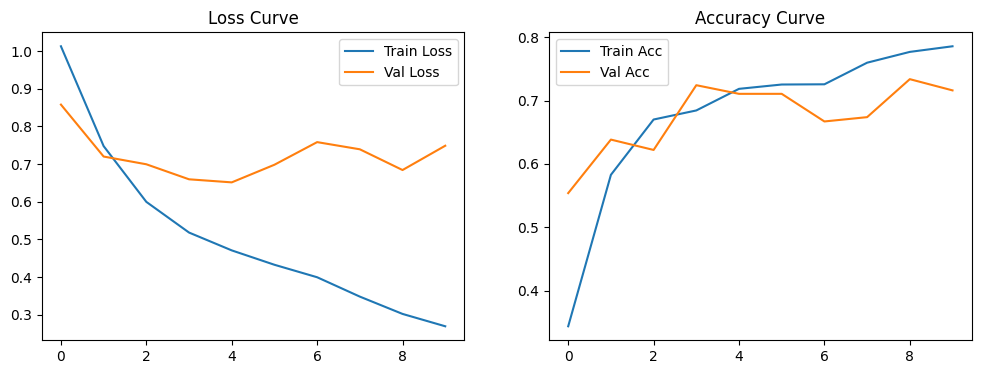

Evaluating: 100%|██████████| 23/23 [00:46<00:00,  2.03s/it]


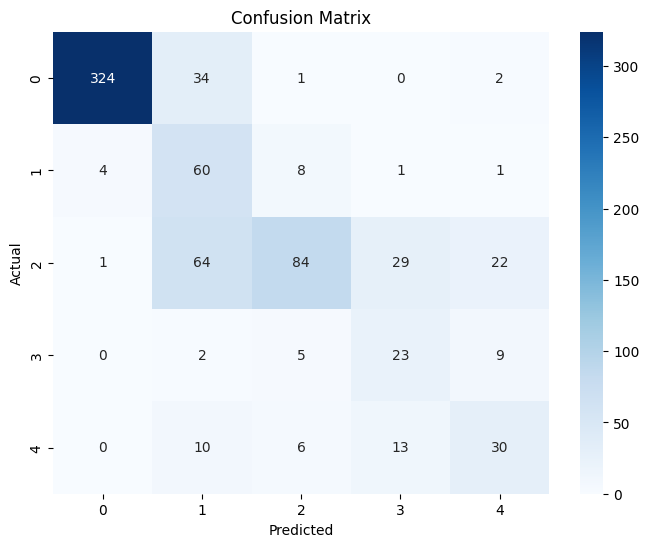

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.98      0.90      0.94       361
     Level 1       0.35      0.81      0.49        74
     Level 2       0.81      0.42      0.55       200
     Level 3       0.35      0.59      0.44        39
     Level 4       0.47      0.51      0.49        59

    accuracy                           0.71       733
   macro avg       0.59      0.65      0.58       733
weighted avg       0.80      0.71      0.73       733

------------------------------
Quadratic Weighted Kappa (QWK): 0.8281
------------------------------


In [6]:
# Plot Training Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

# Generate Predictions on Validation Set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['val'], desc="Evaluating"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=[f'Level {i}' for i in range(5)]))

# IMPROVEMENT 3: Quadratic Weighted Kappa
qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print("-" * 30)
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("-" * 30)

## 6. Model Explainability (Grad-CAM)
To ensure the model is looking at clinically relevant areas (like microaneurysms or exudates) rather than background artifacts, we use Gradient-weighted Class Activation Mapping (Grad-CAM) on the final convolutional layer of our ResNet50.

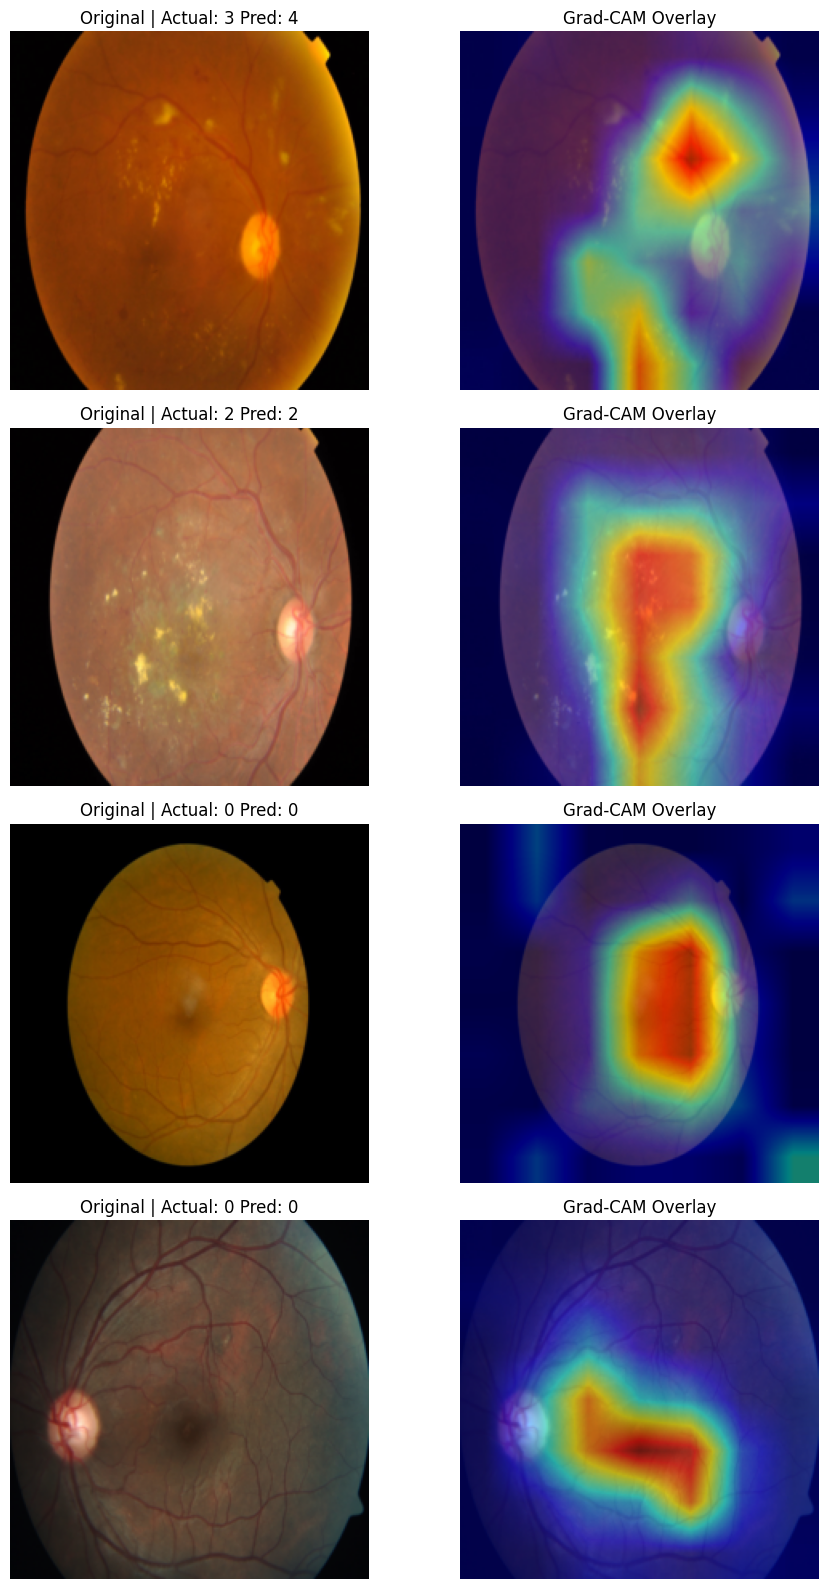

In [7]:
def visualize_gradcam(model, dataset, num_images=4):
    """
    Visualizes original images alongside their Grad-CAM overlays.
    """
    # Grad-CAM operations occasionally face unsupported operations on MPS.
    # We temporarily move the model to CPU for visualization to ensure stability.
    model.to("cpu")
    model.eval()
    
    # Target the final convolutional layer of ResNet50
    target_layers = [model.layer4[-1]]
    
    cam = GradCAM(model=model, target_layers=target_layers)
    
    fig, axes = plt.subplots(num_images, 2, figsize=(10, 4 * num_images))
    
    for i in range(num_images):
        # Grab a random image from the validation set
        idx = np.random.randint(0, len(dataset))
        img_tensor, label = dataset[idx]
        
        # Add batch dimension
        input_tensor = img_tensor.unsqueeze(0).to("cpu")
        
        # Prepare the image for matplotlib (Un-normalize)
        img_np = img_tensor.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        # Generate CAM
        targets = [ClassifierOutputTarget(label.item())]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]
        
        # Overlay CAM on original image
        cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        
        # Predictions
        with torch.no_grad():
            output = model(input_tensor)
            pred = torch.argmax(output, dim=1).item()
            
        # Plotting
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Original | Actual: {label.item()} Pred: {pred}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(cam_image)
        axes[i, 1].set_title('Grad-CAM Overlay')
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()
    
    # Move model back to MPS for future use if needed
    model.to(device)

# Visualize 4 random validation images
visualize_gradcam(model, val_dataset, num_images=4)